In [1]:
library(eSMC2,lib.loc="/data/proj2/home/students/u.srinivasan/R/x86_64-redhat-linux-gnu-library/4.3")
library(patchwork)
library(ggplot2)

In [2]:
# Define mutation rate and generation time
mu <- 2.45e-10
gen <- 0.16

# Initialize lists to store plot data
plot_data_list_newhetfile_esmc2 <- list()
plot_data_list_newhetfile_msmc <- list()
plot_data_list_newhetfile_esmc2_free_r<-list()
# Loop over chromosomes 01 to 14
for (i in 5:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    print(chr)
    
    # Construct the file paths
    filepath_newhetfile_esmc2 <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/VR_Trial_4inds/esmc_chrsep_4inds_out/rm_1000_fixed_r/results_chr_", chr, ".rds")
    filepath_newhetfile_esmc2_free_r<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/VR_Trial_4inds/esmc_chrsep_4inds_out/rm_1_free_r/Viet_Rata_chr", chr, "_top4_individuals.mhs.rds")
    filepath_newhetfile_msmc <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/VR_Trial_4inds/msmc2_chrsep_4inds/Popsize_Viet_Rata_chr", chr, "_top4_individuals.msmc2.final.txt")
    
    # Check if eSMC2 file exists
    if (file.exists(filepath_newhetfile_esmc2)) {
        # Read the eSMC2 data
        maesot_newhetfile_esmc2 <- readRDS(filepath_newhetfile_esmc2)
        # Store the data in the list
        plot_data_list_newhetfile_esmc2[[chr]] <- maesot_newhetfile_esmc2
    } else {
        print(paste("eSMC2 file not found for chromosome", chr))
    }
    #print(filepath_newhetfile_esmc2_free_r)
    # Check if eSMC2 file exists
    if (file.exists(filepath_newhetfile_esmc2_free_r)) {
        # Read the eSMC2 data
        maesot_newhetfile_esmc2_free_r <- readRDS(filepath_newhetfile_esmc2_free_r)
        # Store the data in the list
        plot_data_list_newhetfile_esmc2_free_r[[chr]] <- maesot_newhetfile_esmc2_free_r
    } else {
        print(paste("eSMC2 free r file not found for chromosome", chr))
    }

    # Check if MSMC file exists
    if (file.exists(filepath_newhetfile_msmc)) {
        # Read the MSMC data
        maesot_newhetfile_msmc <- read.table(filepath_newhetfile_msmc, header = TRUE)
        # Store the data in the list
        plot_data_list_newhetfile_msmc[[chr]] <- maesot_newhetfile_msmc
    } else {
        print(paste("MSMC file not found for chromosome", chr))
    }
}


[1] "05"
[1] "06"
[1] "07"
[1] "08"
[1] "09"
[1] "10"
[1] "11"
[1] "12"
[1] "eSMC2 free r file not found for chromosome 12"
[1] "13"
[1] "14"


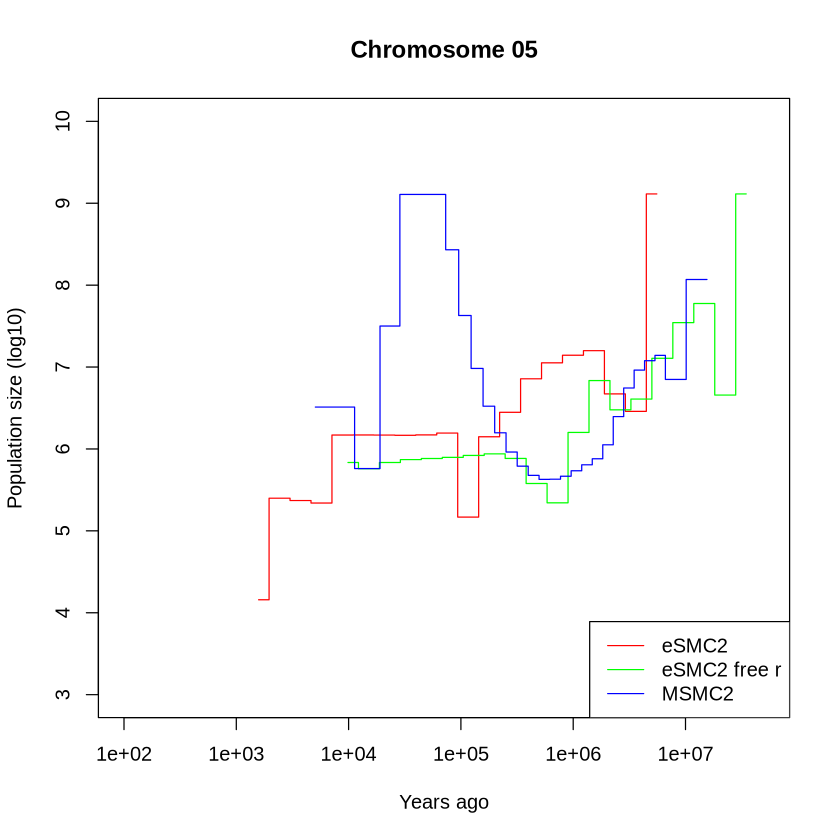

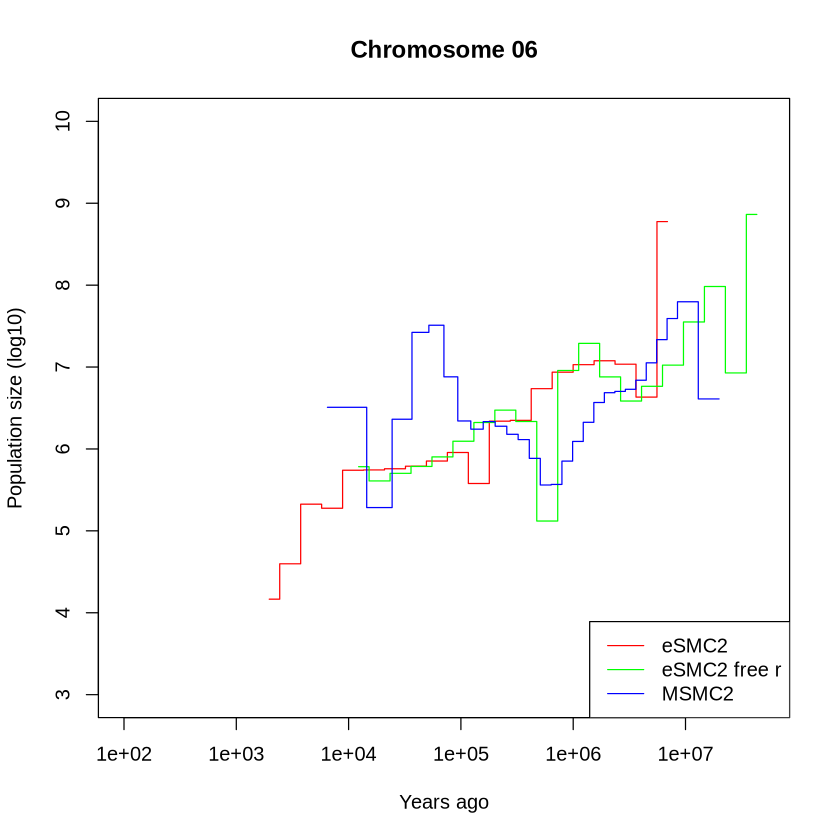

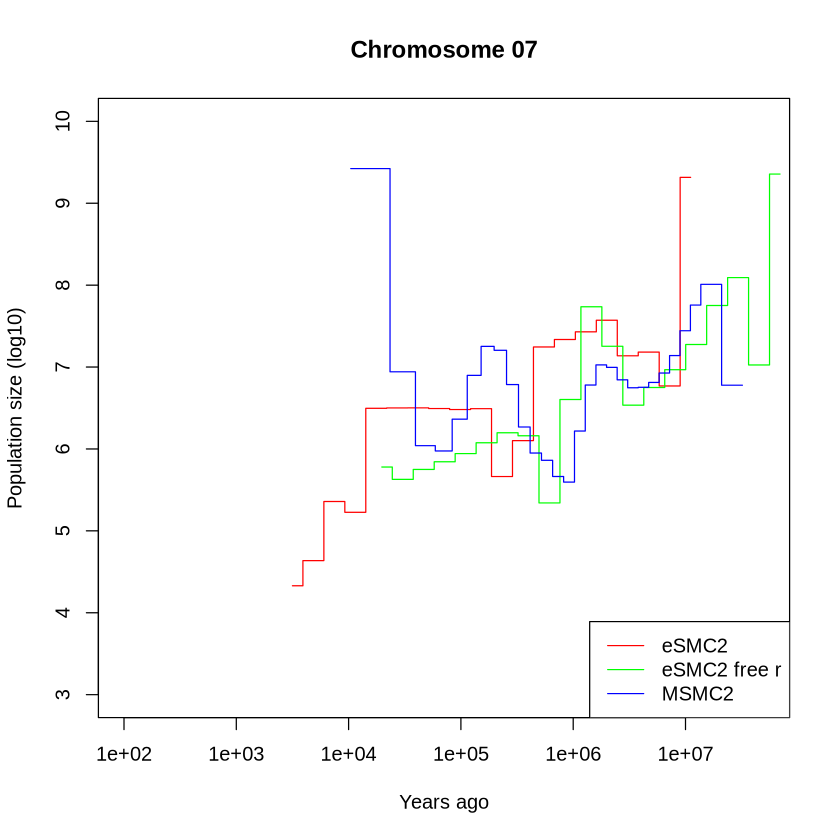

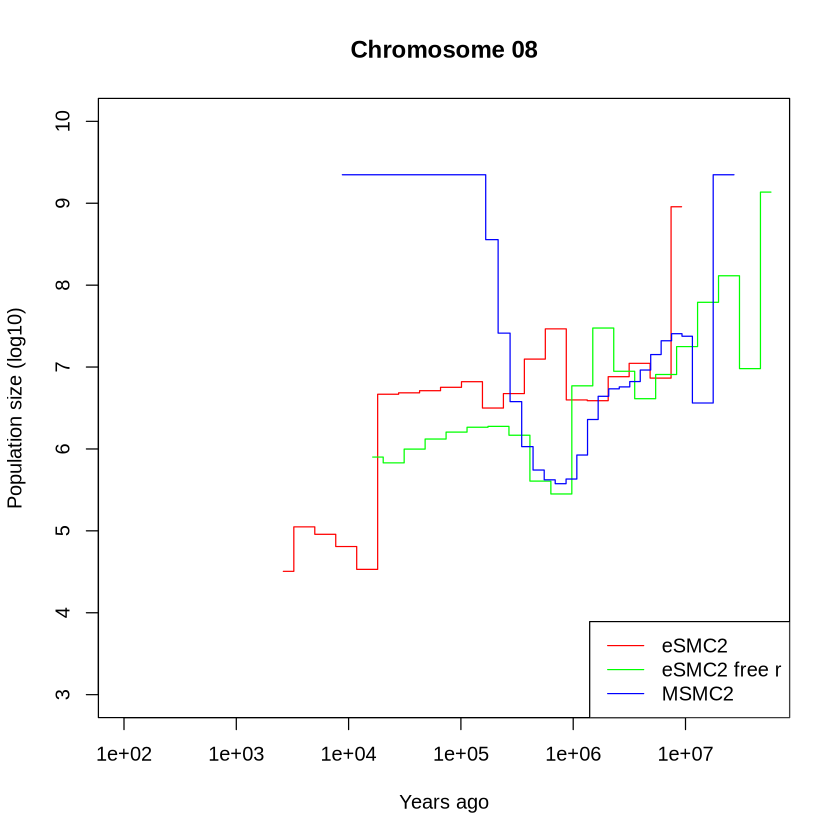

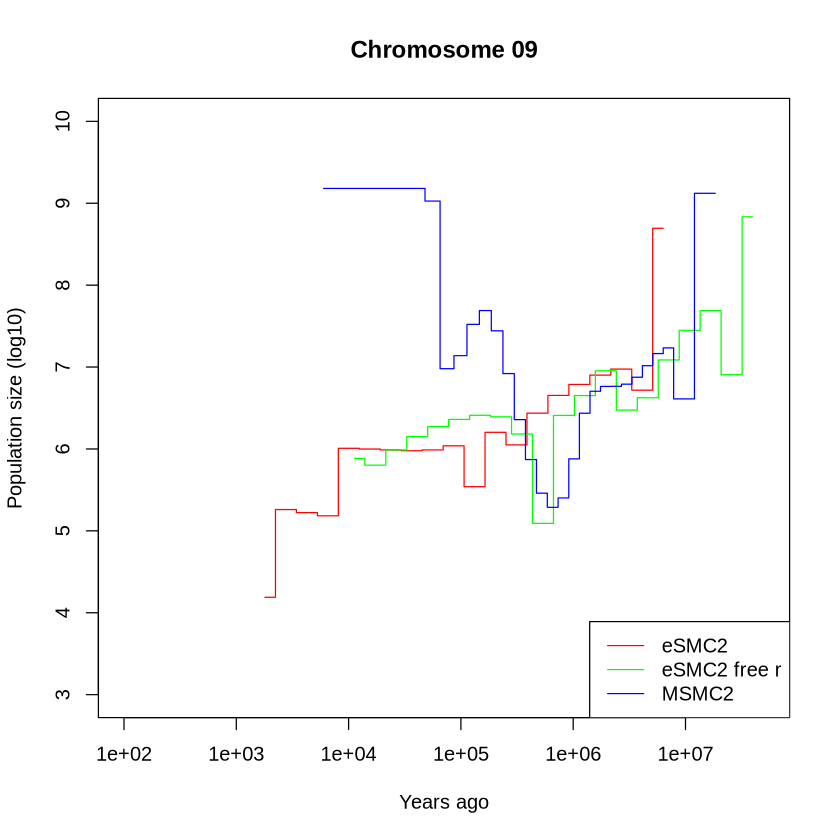

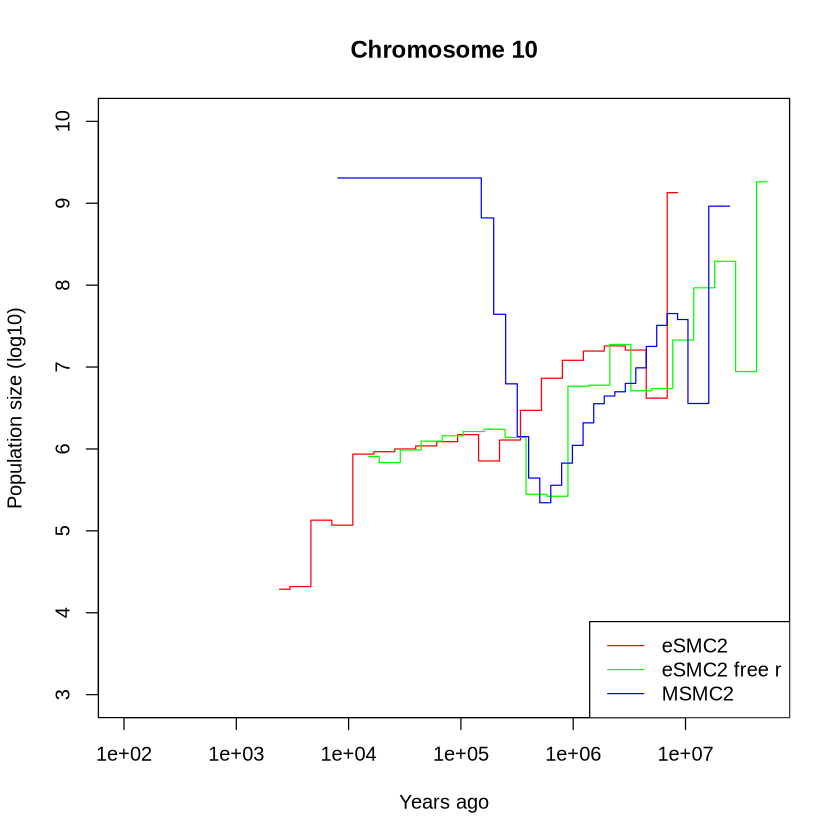

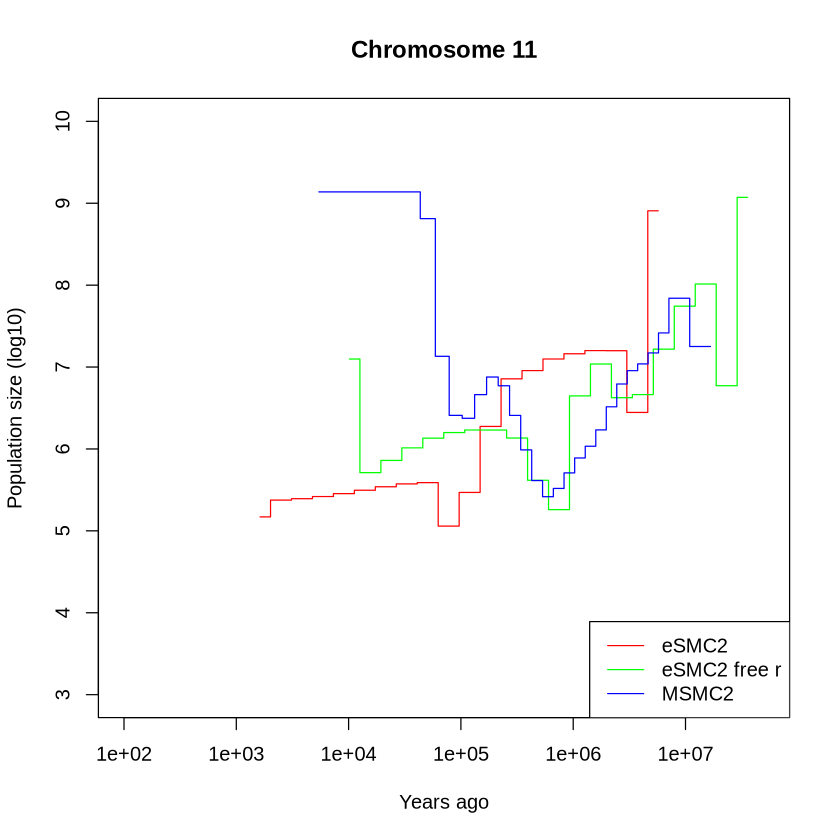

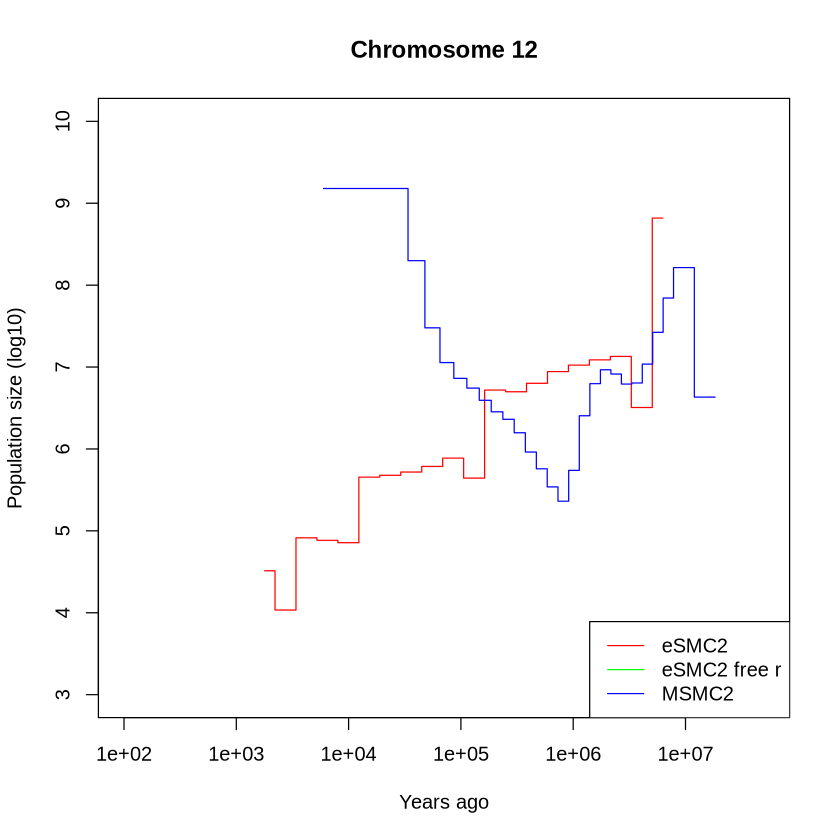

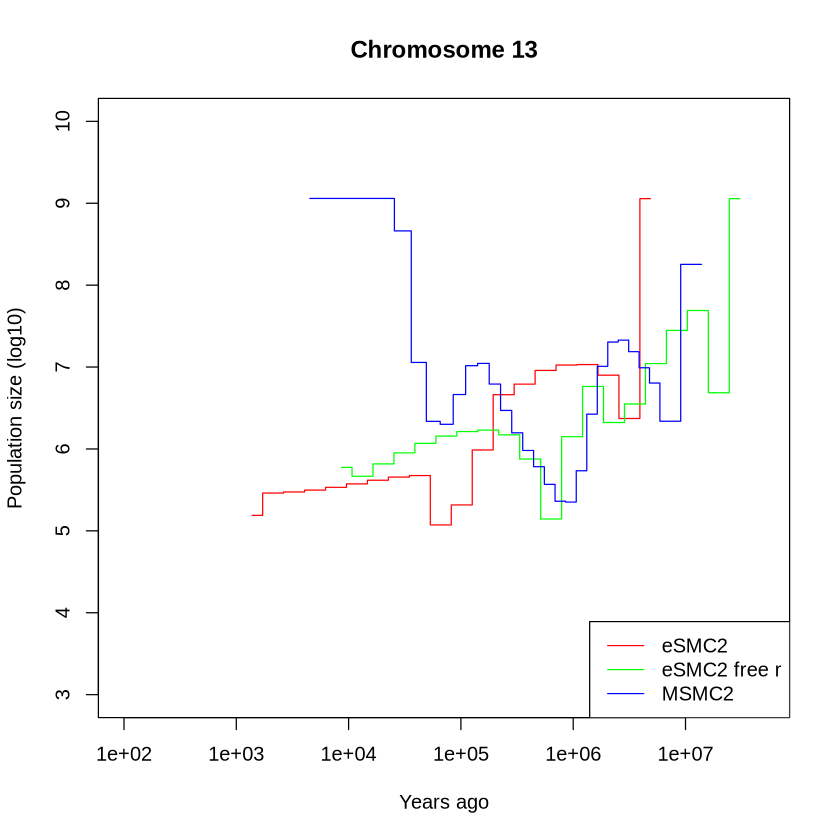

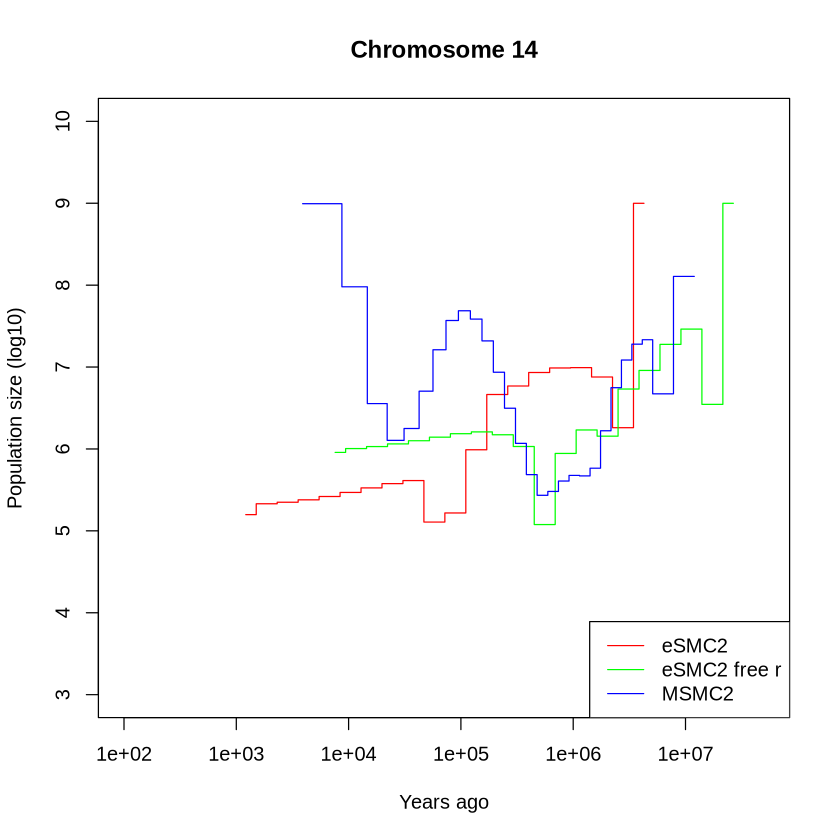

In [4]:
# Set the background color to white
par(bg = "white")  # Applies white background to all plots

# Plot each chromosome data in separate plots
for (chr in union(names(plot_data_list_newhetfile_esmc2), names(plot_data_list_newhetfile_msmc))) {

    # Extract data for the current chromosome
    maesot_newhetfile_esmc2 <- plot_data_list_newhetfile_esmc2[[chr]]
    maesot_newhetfile_msmc <- plot_data_list_newhetfile_msmc[[chr]]
    maesot_esmc2_free_r<- plot_data_list_newhetfile_esmc2_free_r[[chr]]

    # Create the plot with a white background
    plot(c(1000, 2 * 10^6),
         c(1, 1), 
         log = "x", 
         ylim = c(3, 10),
         xlim=c(100, 50000000),
         type = "n", 
         xlab = "Years ago", 
         ylab = "Population size (log10)",
         main = paste("Chromosome", chr),
         bg = "white")  # Explicitly set background to white here if needed


    Ne_t <- maesot_newhetfile_esmc2$Xi
    Ne <- mean(maesot_newhetfile_esmc2$mu / mu)
    # Plot eSMC2 data if available
    if (!is.null(maesot_newhetfile_esmc2)) {
        lines(maesot_newhetfile_esmc2$Tc * Ne * gen,
               log10(Ne_t * Ne), 
              type = "s", col = "red")
    }

    Ne_t <- maesot_esmc2_free_r$Xi
    Ne <- mean(maesot_esmc2_free_r$mu / mu)
    # Plot eSMC2 data if available
    if (!is.null(maesot_esmc2_free_r)) {
        lines(maesot_esmc2_free_r$Tc * Ne , #* gen,
               log10(Ne_t * Ne), 
              type = "s", col = "green")
    }

    # Plot MSMC data if available
    if (!is.null(maesot_newhetfile_msmc)) {
        lines(maesot_newhetfile_msmc$left_time_boundary / mu ,#* gen,
              log10((1 / maesot_newhetfile_msmc$lambda) / (mu)), 
              type = "s", col = "blue")
    }

    # Add legend only if data from at least one method is plotted
    if (!is.null(maesot_newhetfile_esmc2) || !is.null(maesot_newhetfile_msmc)) {
        legend("bottomright", legend = c("eSMC2", "eSMC2 free r","MSMC2"), col = c("red","green", "blue"), lty = c(1,1, 1))
    }
}



In [2]:

# Initialize lists to store plot data for each chromosome and "All Chromosome"
plot_data_list_newhetfile_esmc2 <- list()
plot_data_list_newhetfile_esmc2_free_r <- list()
plot_data_list_newhetfile_msmc <- list()

# Loop over each chromosome to load eSMC2 and MSMC data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # Construct the file paths
    filepath_newhetfile_esmc2 <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/fixed_r/results_chr_", chr, ".rds")
    filepath_newhetfile_esmc2_free_r<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r/mut_rate_4.0425e-09/Viet_Rata_chr", chr, "_top4_individuals.mhs.rds")
    filepath_newhetfile_msmc <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/VR_Trial_4inds/msmc2_chrsep_4inds/Popsize_Viet_Rata_chr", chr, "_top4_individuals.msmc2.final.txt")
    
    # Load eSMC2 data if available
    if (file.exists(filepath_newhetfile_esmc2)) {
        maesot_esmc2 <- readRDS(filepath_newhetfile_esmc2)
        plot_data_list_newhetfile_esmc2[[chr]] <- maesot_esmc2
    } else {
        message(paste("eSMC2 file not found for chromosome", chr))
    }
    
    # Load eSMC2 data if available
    if (file.exists(filepath_newhetfile_esmc2_free_r)) {
        maesot_esmc2_free_r <- readRDS(filepath_newhetfile_esmc2_free_r)
        plot_data_list_newhetfile_esmc2_free_r[[chr]] <- maesot_esmc2_free_r
    } else {
        message(paste("eSMC2 file not found for chromosome", chr))
    }

    # Load MSMC data if available
    if (file.exists(filepath_newhetfile_msmc)) {
        maesot_msmc <- read.table(filepath_newhetfile_msmc, header = TRUE)
        plot_data_list_newhetfile_msmc[[chr]] <- maesot_msmc
    } else {
        message(paste("MSMC file not found for chromosome", chr))
    }
}

# Load "All Chromosome" files for eSMC2 and MSMC
filepath_esmc2_allchr <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/fixed_r/results_allchr.rds"
filepath_esmc2_allchr_free_r <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r/results_allchr_free_r.rds"
filepath_msmc_allchr <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/VR_Trial_4inds/msmc2_allchr_4inds_outs/msmc2_multchrom.final.txt"

# Load "All Chromosome" eSMC2 data
if (file.exists(filepath_esmc2_allchr)) {
    maesot_esmc2_allchr <- readRDS(filepath_esmc2_allchr)
    plot_data_list_newhetfile_esmc2[["allchr"]] <- maesot_esmc2_allchr
} else {
    message("All Chromosome eSMC2 file not found.")
}

# Load "All Chromosome" eSMC2 data
if (file.exists(filepath_esmc2_allchr_free_r)) {
    maesot_esmc2_allchr_free_r <- readRDS(filepath_esmc2_allchr_free_r)
    plot_data_list_newhetfile_esmc2_free_r[["allchr"]] <- maesot_esmc2_allchr_free_r
} else {
    message("All Chromosome eSMC2 file not found.")
}
# Load "All Chromosome" MSMC data
if (file.exists(filepath_msmc_allchr)) {
    maesot_msmc_allchr <- read.table(filepath_msmc_allchr, header = TRUE)
    plot_data_list_newhetfile_msmc[["allchr"]] <- maesot_msmc_allchr
} else {
    message("All Chromosome MSMC file not found.")
}


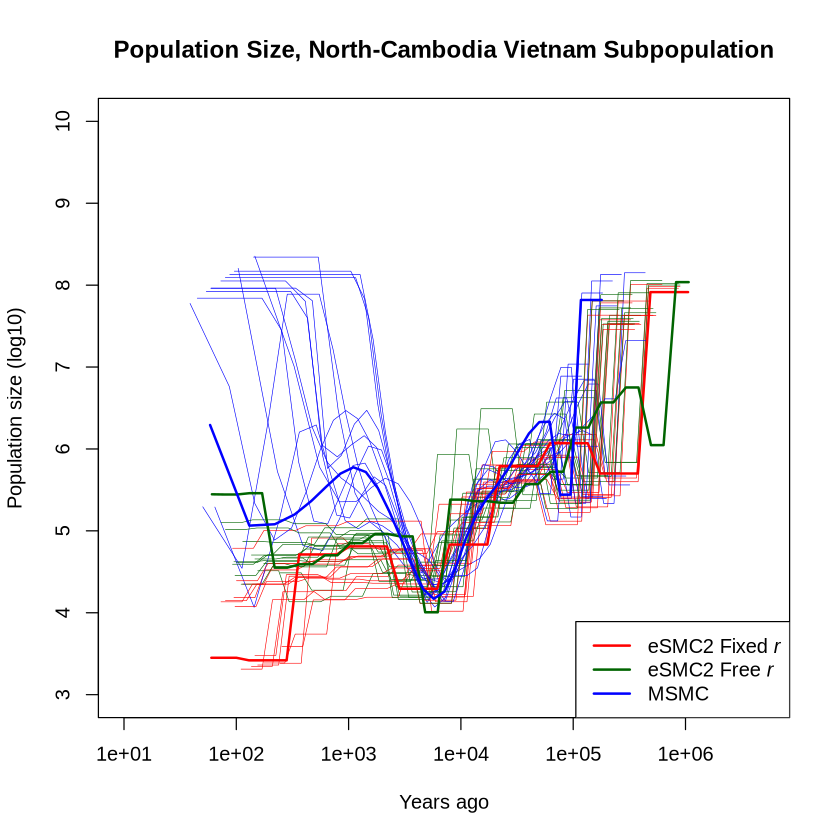

In [3]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.164   # Generation time

par(bg = "white")  # Applies white background to all plots

# Set up plot area with logarithmic x-axis
plot(c(1000, 5 * 10^7), 
     c(1, 1), 
     log = "x", 
     ylim = c(3, 10), 
     xlim = c(10, 5 * 10^6), 
     type = "n", 
     xlab = "Years ago", 
     ylab = "Population size (log10)", 
     main = "Population Size, North-Cambodia Vietnam Subpopulation")

# Loop through each chromosome to plot lighter lines for individual chromosomes
for (chr in names(plot_data_list_newhetfile_esmc2)) {
  # Skip if "allchr" as we will plot it separately
  if (chr != "allchr") {
    # eSMC2 plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2[[chr]]$mu / mu)
      lines(plot_data_list_newhetfile_esmc2[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "red", lwd = 0.5)
    }
    
    # eSMC2 Free_r plot for each chromosome (mu = 1e-08)
    if (!is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)  # Fixed mu for free_r
      lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)  # Orange color for free_r
    }

    # MSMC plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_msmc[[chr]])) {
      lines(plot_data_list_newhetfile_msmc[[chr]]$left_time_boundary / mu * gen,
            log10((1 / plot_data_list_newhetfile_msmc[[chr]]$lambda) / mu), 
            col = "blue", lwd = 0.5)
    }
  }
}

# Plot "All Chromosome" lines in bold
# eSMC2 "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "red", lwd = 2)
}

# eSMC2 Free_r "All Chromosome" (mu = 1e-08)
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}

# MSMC "All Chromosome"
if (!is.null(plot_data_list_newhetfile_msmc[["allchr"]])) {
  lines(plot_data_list_newhetfile_msmc[["allchr"]]$left_time_boundary / mu * gen,
        log10((1 / plot_data_list_newhetfile_msmc[["allchr"]]$lambda) / mu), 
        col = "blue", lwd = 2)
}

# Add a legend for the main lines
legend("bottomright", 
       legend = c(expression("eSMC2 Fixed "*italic(r)), 
                  expression("eSMC2 Free "*italic(r)), 
       "MSMC"),
       col = c("red", "darkgreen", "blue"), lty = 1, lwd = 2)



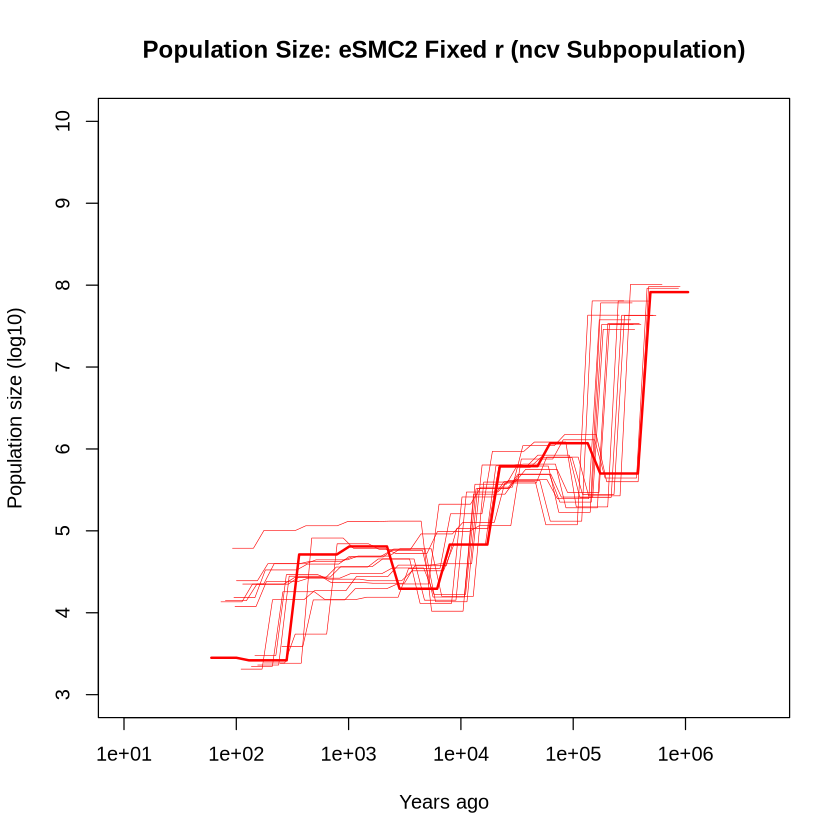

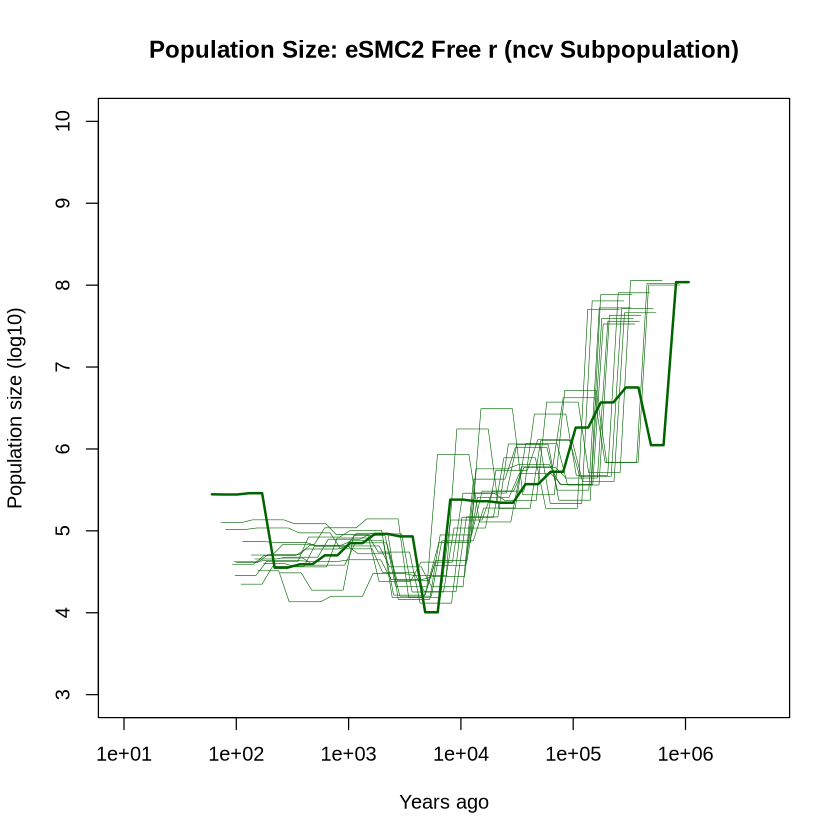

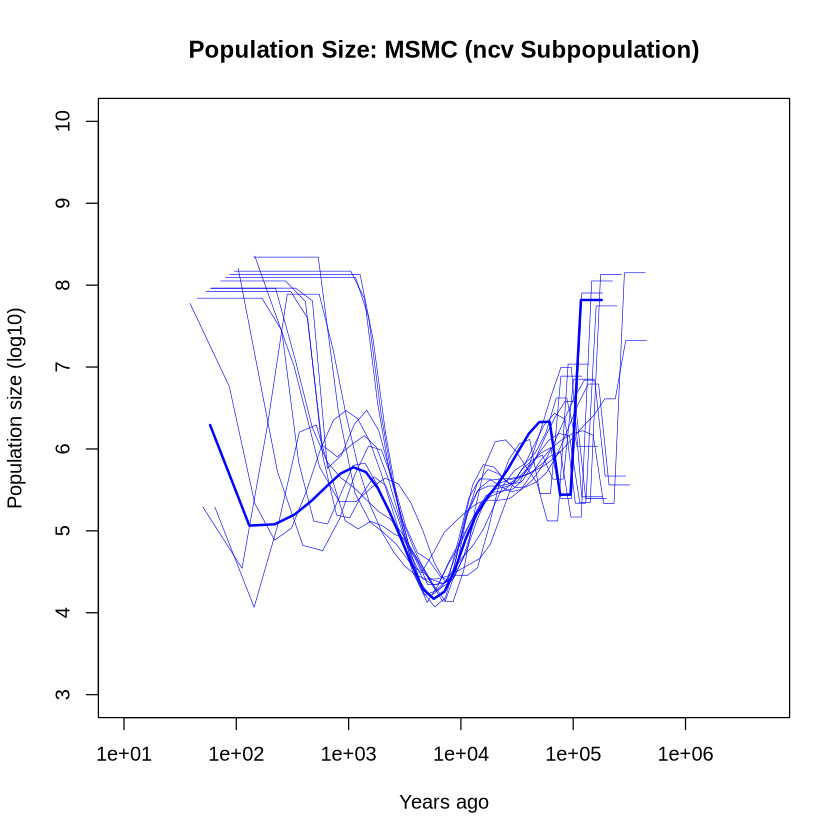

In [5]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.164      # Generation time

par(bg = "white")  # Applies white background to all plots

# Function to set up the plotting area
setup_plot <- function(title) {
  plot(c(1000, 5 * 10^7), 
       c(1, 1), 
       log = "x", 
       ylim = c(3, 10), 
       xlim = c(10, 5 * 10^6), 
       type = "n", 
       xlab = "Years ago", 
       ylab = "Population size (log10)", 
       main = title)
}

# Plot eSMC2 Fixed r
setup_plot("Population Size: eSMC2 Fixed r (ncv Subpopulation)")
for (chr in names(plot_data_list_newhetfile_esmc2)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2[[chr]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2[[chr]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2[[chr]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2[[chr]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "red", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_esmc2[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "red", lwd = 2)
}

# Plot eSMC2 Free r
setup_plot("Population Size: eSMC2 Free r (ncv Subpopulation)")
for (chr in names(plot_data_list_newhetfile_esmc2_free_r)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}

# Plot MSMC
setup_plot("Population Size: MSMC (ncv Subpopulation)")
for (chr in names(plot_data_list_newhetfile_msmc)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_msmc[[chr]])) {
    lines(plot_data_list_newhetfile_msmc[[chr]]$left_time_boundary / mu * gen,
          log10((1 / plot_data_list_newhetfile_msmc[[chr]]$lambda) / mu), 
          col = "blue", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_msmc[["allchr"]])) {
  lines(plot_data_list_newhetfile_msmc[["allchr"]]$left_time_boundary / mu * gen,
        log10((1 / plot_data_list_newhetfile_msmc[["allchr"]]$lambda) / mu), 
        col = "blue", lwd = 2)
}

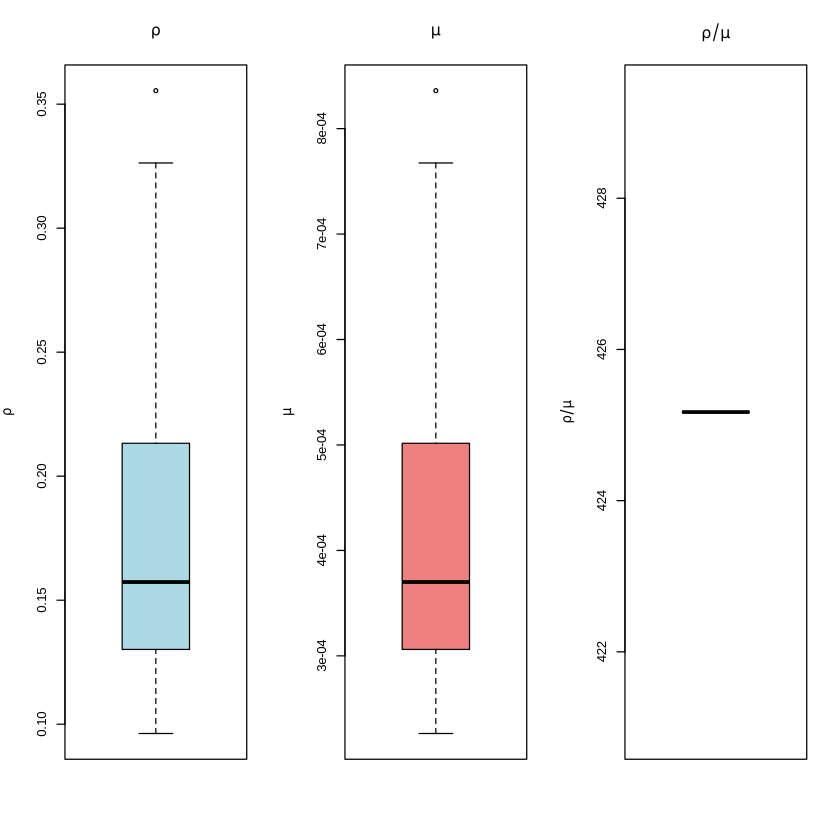

In [33]:
# Extract rho, mu, and rho/mu for each chromosome
rho_values_esmc2 <- sapply(plot_data_list_newhetfile_esmc2, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$rho)
    } else {
        return(NA)  # Handle missing data
    }
})

mu_values_esmc2 <- sapply(plot_data_list_newhetfile_esmc2, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$mu)
    } else {
        return(NA)  # Handle missing data
    }
})

rho_mu_ratios_esmc2 <- sapply(plot_data_list_newhetfile_esmc2, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$rho / chr_data$mu)
    } else {
        return(NA)  # Handle missing data
    }
})

# Remove chromosomes with missing data
valid_indices_esmc2 <- !is.na(rho_values_esmc2) & !is.na(rho_mu_ratios_esmc2) & !is.na(mu_values_esmc2)
rho_values_esmc2 <- rho_values_esmc2[valid_indices_esmc2]
rho_mu_ratios_esmc2 <- rho_mu_ratios_esmc2[valid_indices_esmc2]
mu_values_esmc2 <- mu_values_esmc2[valid_indices_esmc2]

# Create a data frame for plotting
boxplot_data_esmc2 <- data.frame(
    Chromosome = names(rho_values_esmc2),
    Rho = rho_values_esmc2,
    Rho_Mu_Ratio = rho_mu_ratios_esmc2,
    Mu = mu_values_esmc2
)

# Set up plotting layout
par(mfrow = c(1, 3), bg = "white")  # Arrange plots in one row with three columns

# Boxplot for rho
boxplot(boxplot_data_esmc2$Rho,
        main = expression(rho),
        ylab = expression(rho),
        col = "lightblue")


# Boxplot for mu
boxplot(boxplot_data_esmc2$Mu,
        main = expression(mu),
        ylab = expression(mu),
        col = "lightcoral")

# Boxplot for rho/mu
boxplot(boxplot_data_esmc2$Rho_Mu_Ratio,
        main = expression(rho / mu),
        ylab = expression(rho / mu),
        col = "lightgreen")

# Reset plotting layout
par(mfrow = c(1, 1), bg = "white")


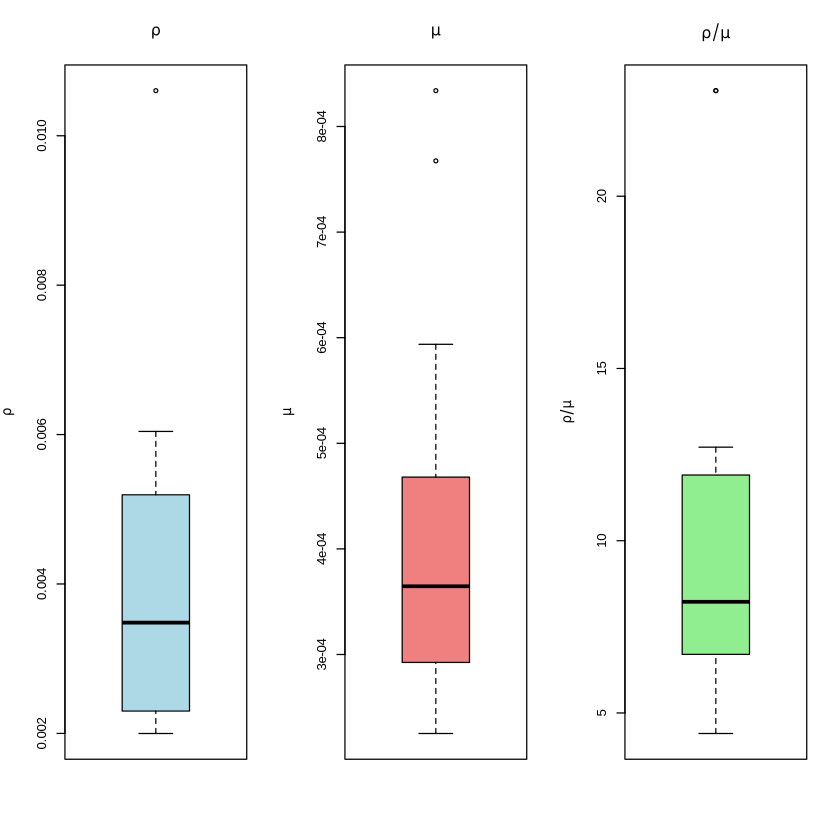

In [31]:
# Extract rho, mu, and rho/mu for each chromosome
rho_values <- sapply(plot_data_list_newhetfile_esmc2_free_r, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$rho)
    } else {
        return(NA)  # Handle missing data
    }
})

mu_values <- sapply(plot_data_list_newhetfile_esmc2_free_r, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$mu)
    } else {
        return(NA)  # Handle missing data
    }
})

rho_mu_ratios <- sapply(plot_data_list_newhetfile_esmc2_free_r, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$rho / chr_data$mu)
    } else {
        return(NA)  # Handle missing data
    }
})

# Remove chromosomes with missing data
valid_indices <- !is.na(rho_values) & !is.na(rho_mu_ratios) & !is.na(mu_values)
rho_values <- rho_values[valid_indices]
rho_mu_ratios <- rho_mu_ratios[valid_indices]
mu_values <- mu_values[valid_indices]

# Create a data frame for plotting
boxplot_data <- data.frame(
    Chromosome = names(rho_values),
    Rho = rho_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Mu = mu_values
)

# Set up plotting layout
par(mfrow = c(1, 3), bg = "white")  # Arrange plots in one row with three columns

# Boxplot for rho
boxplot(boxplot_data$Rho,
        main = expression(rho),
        ylab = expression(rho),
        col = "lightblue")

# Boxplot for mu
boxplot(boxplot_data$Mu,
        main = expression(mu),
        ylab = expression(mu),
        col = "lightcoral")

# Boxplot for rho/mu
boxplot(boxplot_data$Rho_Mu_Ratio,
        main = expression(rho / mu),
        ylab = expression(rho / mu),
        col = "lightgreen")


# Reset plotting layout
par(mfrow = c(1, 1), bg = "white")



In [4]:

# Directories for various eSMC2 datasets
base_dir_regions_free_r <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r_regions/mut_rate_4.0425e-09/"
base_dir_free_r <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r/mut_rate_4.0425e-09/"

# Initialize lists to store the data
plot_data_list_newhetfile_esmc2_regions <- list()
plot_data_list_newhetfile_esmc2_free_r <- list()
plot_data_list_newhetfile_esmc2_regions_free_r <- list()

# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # ----- Load Region-specific eSMC2 Free r Files -----
    # Construct a search pattern for region files
    search_pattern_regions <- paste0("Viet_Rata_chr", chr, "_top4_individuals_region_.*\\.rds")
    region_files <- list.files(path = base_dir_regions_free_r, pattern = search_pattern_regions, full.names = TRUE)

    # Check and load all region files for the current chromosome
    
    data_list_regions <- lapply(region_files, readRDS)  # Read RDS files
    plot_data_list_newhetfile_esmc2_regions[[chr]] <- data_list_regions
    
    
   
}

In [5]:




# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    # ----- Load eSMC2 Free r Files -----
    filepath_free_r <- paste0(base_dir_free_r, "Viet_Rata_chr", chr, "_top4_individuals.mhs.rds")
    print(filepath_free_r)
    if (file.exists(filepath_free_r)) {
        maesot_esmc2_free_r <- readRDS(filepath_free_r)
        plot_data_list_newhetfile_esmc2_free_r[[chr]] <- maesot_esmc2_free_r
    } else {
        message(paste("eSMC2 Free r file not found for chromosome", chr))
    }
    
}

[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r/mut_rate_4.0425e-09/Viet_Rata_chr01_top4_individuals.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r/mut_rate_4.0425e-09/Viet_Rata_chr02_top4_individuals.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r/mut_rate_4.0425e-09/Viet_Rata_chr03_top4_individuals.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r/mut_rate_4.0425e-09/Viet_Rata_chr04_top4_individuals.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r/mut_rate_4.0425e-09/Viet_Rata_chr05_top4_individuals.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r/mut_rate_4.0425e-09/Viet_Rata_chr06_top4_individuals.mhs.rds"
[1] "/data/proj2/home/

In [6]:

# ----- Load "All Chromosome" Files -----
# Paths for "All Chromosome" files
filepath_allchr_regions_free_r <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r_regions/results_allchr_regions_free_r.rds")
#filepath_allchr_regions_free_r <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r_regions/results_allchr_regions_free_r.rds")
filepath_allchr_free_r <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/vr_t2/free_r/results_allchr_free_r.rds")

# Load "All Chromosome" Region-specific data
if (file.exists(filepath_allchr_regions_free_r)) {
    data_allchr_regions <- readRDS(filepath_allchr_regions_free_r)
    plot_data_list_newhetfile_esmc2_regions[["allchr"]] <- data_allchr_regions
} else {
    message("All Chromosome region-specific file not found.")
}

# Load "All Chromosome" Free r data
if (file.exists(filepath_allchr_free_r)) {
    data_allchr_free_r <- readRDS(filepath_allchr_free_r)
    plot_data_list_newhetfile_esmc2_free_r[["allchr"]] <- data_allchr_free_r
} else {
    message("All Chromosome eSMC2 Free r file not found.")
}


str(plot_data_list_newhetfile_esmc2_regions)
#str(plot_data_list_newhetfile_esmc2_free_r)



List of 15
 $ 01    :List of 1
  ..$ :List of 8
  .. ..$ LH   : num 13089
  .. ..$ Tc   : num [1:40] 0 0.0076 0.00942 0.01168 0.01448 ...
  .. ..$ Xi   : num [1:40] 0.473 0.473 0.473 0.473 0.215 ...
  .. ..$ mu   : num 0.000484
  .. ..$ L    : num 575559
  .. ..$ beta : num 1
  .. ..$ sigma: num 0
  .. ..$ rho  : num 0.0104
 $ 02    :List of 1
  ..$ :List of 8
  .. ..$ LH   : num 17263
  .. ..$ Tc   : num [1:40] 0 0.0076 0.00942 0.01168 0.01448 ...
  .. ..$ Xi   : num [1:40] 3.893 3.893 3.893 3.893 0.534 ...
  .. ..$ mu   : num 0.000303
  .. ..$ L    : num 861226
  .. ..$ beta : num 1
  .. ..$ sigma: num 0
  .. ..$ rho  : num 0.011
 $ 03    :List of 1
  ..$ :List of 8
  .. ..$ LH   : num 18259
  .. ..$ Tc   : num [1:40] 0 0.0076 0.00942 0.01168 0.01448 ...
  .. ..$ Xi   : num [1:40] 0.246 0.246 0.246 0.246 6.272 ...
  .. ..$ mu   : num 0.000239
  .. ..$ L    : num 1e+06
  .. ..$ beta : num 1
  .. ..$ sigma: num 0
  .. ..$ rho  : num 0.00697
 $ 04    :List of 1
  ..$ :List of 8
  .. ..$

In [7]:

# Define directories for the regions_fixed_r data
base_regions_fixed_r <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/VR_Trial_4inds/esmc_chrsep_4inds_out/regions_fixed_r/params_v3/mut_rate_4.4025e-09"

# Initialize list for regions_fixed_r data
plot_data_list_newhetfile_esmc2_regions_fixed_r <- list()

# Loop over each chromosome to load regions_fixed_r data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # ----- Load Region-specific Fixed r Files ----- 
    # Construct a search pattern for region files
    search_pattern_regions_fixed_r <- paste0("Viet_Rata_chr", chr, "_top4_individuals_region_.*\\.rds")
    region_files_fixed_r <- list.files(path = base_regions_fixed_r, pattern = search_pattern_regions_fixed_r, full.names = TRUE)
    print(region_files_fixed_r)
    
    # Check and load all region files for the current chromosome
    if (length(region_files_fixed_r) > 0) {
        data_list_regions_fixed_r <- lapply(region_files_fixed_r, readRDS)  # Read RDS files
        plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]] <- data_list_regions_fixed_r
    } else {
        message(paste("No region-specific Fixed r files found for chromosome", chr))
    }
}

# ----- Load "All Chromosome" Files for Fixed r -----
# Paths for "All Chromosome" Fixed r files
filepath_allchr_regions_fixed_r <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/Ms_Trial_4inds/esmc_4inds_allchr/me_09/results_allchr_regions.rds")

# Load "All Chromosome" Fixed r region-specific data
if (file.exists(filepath_allchr_regions_fixed_r)) {
    data_allchr_regions_fixed_r <- readRDS(filepath_allchr_regions_fixed_r)
    plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]] <- data_allchr_regions_fixed_r
} else {
    message("All Chromosome Fixed r region-specific file not found.")
}

# Check the structure of the loaded data
str(plot_data_list_newhetfile_esmc2_regions_fixed_r)



[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/VR_Trial_4inds/esmc_chrsep_4inds_out/regions_fixed_r/params_v3/mut_rate_4.4025e-09/Viet_Rata_chr01_top4_individuals_region_92901-457931,460312-575900.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/VR_Trial_4inds/esmc_chrsep_4inds_out/regions_fixed_r/params_v3/mut_rate_4.4025e-09/Viet_Rata_chr02_top4_individuals_region_105801-447300,450451-862500.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/VR_Trial_4inds/esmc_chrsep_4inds_out/regions_fixed_r/params_v3/mut_rate_4.4025e-09/Viet_Rata_chr03_top4_individuals_region_70631-597816,600276-1003060.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/VR_Trial_4inds/esmc_chrsep_4inds_out/regions_fixed_r/params_v3/mut_rate_4.4025e-09/Viet_Rata_chr04_top4_individuals_region_91421-545800,614901-642003,644530-935030,98308

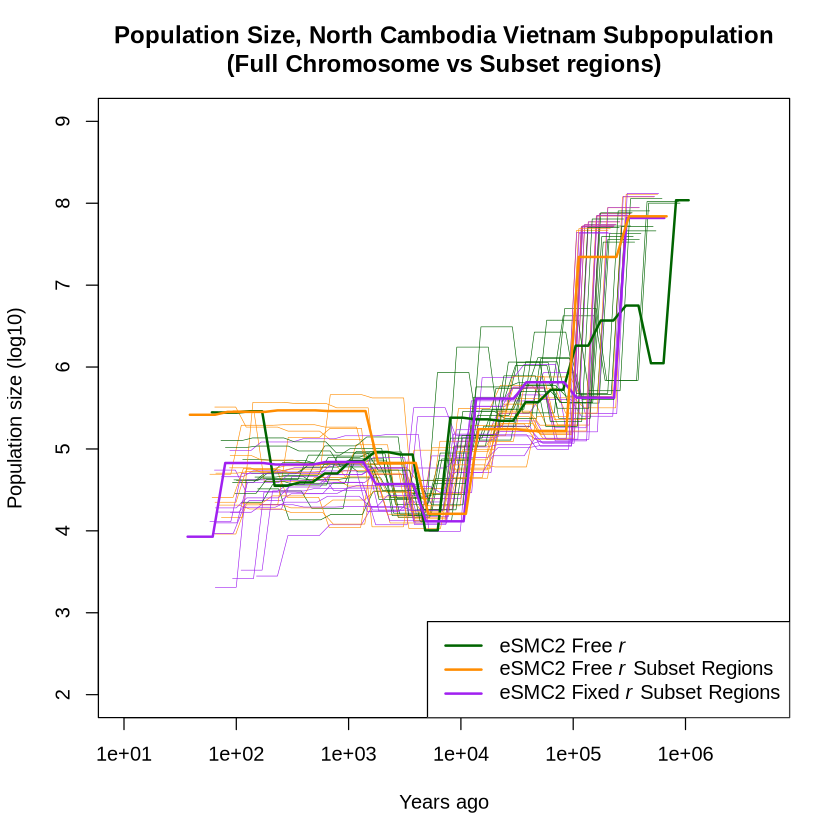

In [8]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.164     # Generation time

par(bg = "white")  # Applies white background to all plots

# Set up plot area with logarithmic x-axis
plot(c(1000, 5 * 10^7), 
     c(1, 1), 
     log = "x", 
     ylim = c(2, 9), 
     xlim = c(10, 5 * 10^6), 
     type = "n", 
     xlab = "Years ago", 
     ylab = "Population size (log10)", 
     main = paste("Population Size, North Cambodia Vietnam Subpopulation", 
             "(Full Chromosome vs Subset regions)", sep = "\n"))


# Loop through each chromosome to plot lighter lines for individual chromosomes
for (chr in names(plot_data_list_newhetfile_esmc2_free_r)) {

  # Skip "allchr" as it will be plotted separately
  if (chr != "allchr") {
    # eSMC2 Free_r plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)  # Fixed mu for Free_r
      lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)  # Green for Free_r
    }
    
    # eSMC2 Free_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_regions[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$mu / mu)  # Fixed mu for Regions
      lines(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkorange", lwd = 0.5)  # Orange for Free_r Regions
    }
    
    # eSMC2 Fixed_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$mu / mu)  # Fixed mu for Fixed_r
      lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "purple", lwd = 0.5)  # Blue for Fixed_r Regions
    }
  }
}

# Plot "All Chromosome" lines in bold
# eSMC2 Free_r "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}


# eSMC2 Fixed_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "purple", lwd = 2)
}

# eSMC2 Free_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkorange", lwd = 2)
}


# Add a legend for the main lines
legend("bottomright", 
       legend = c(expression("eSMC2 Free "*italic(r)), 
                  expression("eSMC2 Free "*italic(r)*" Subset Regions"), 
                  expression("eSMC2 Fixed "*italic(r)*" Subset Regions")),
       col = c("darkgreen", "darkorange", "purple"), 
       lty = 1, 
       lwd = 2)


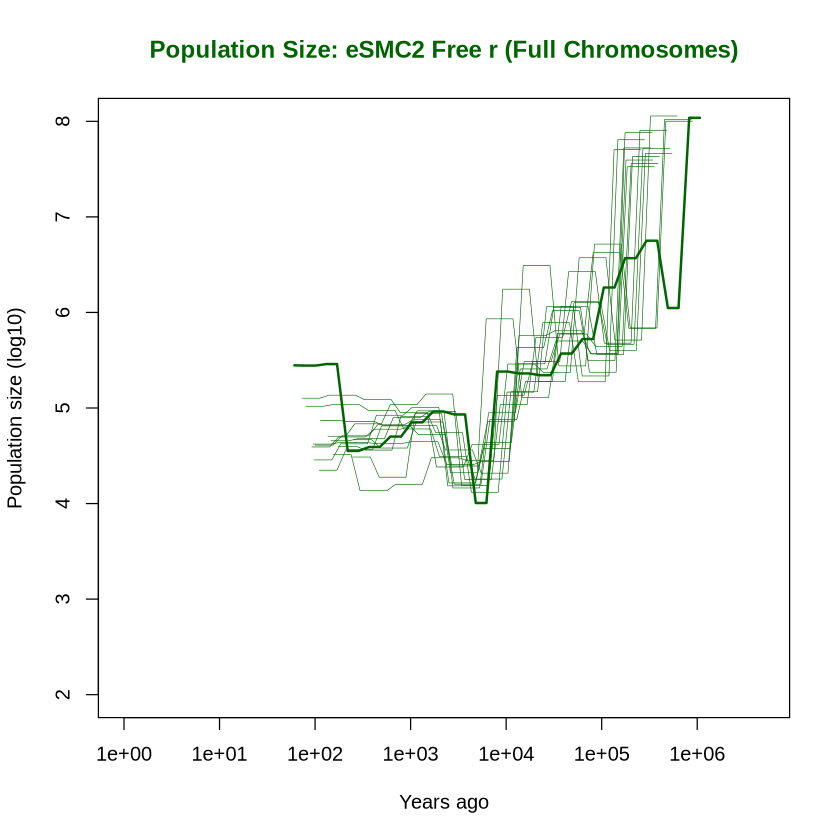

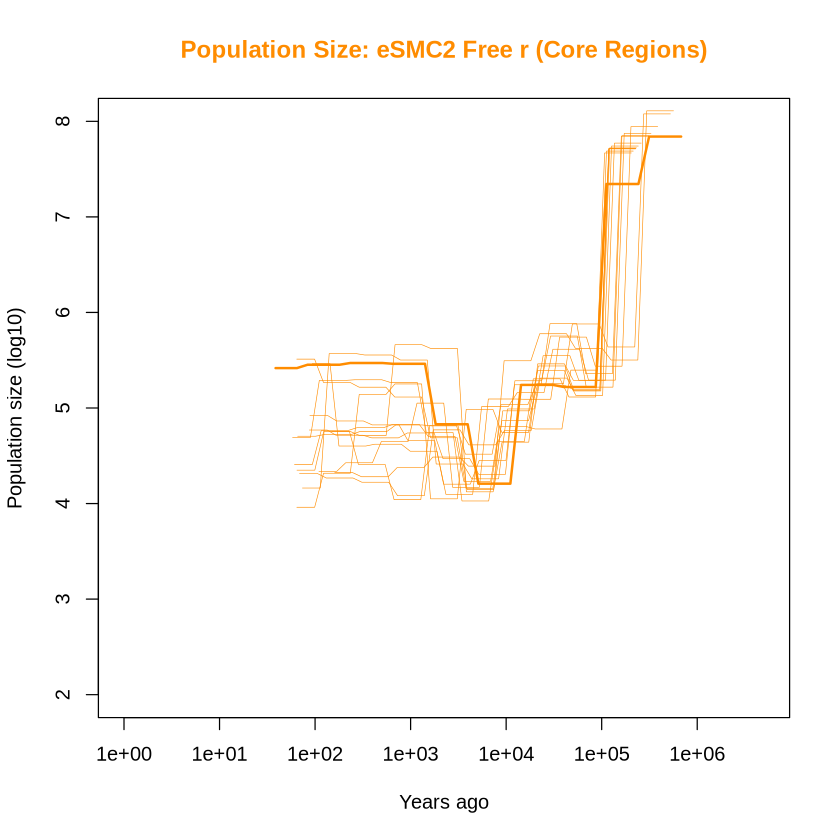

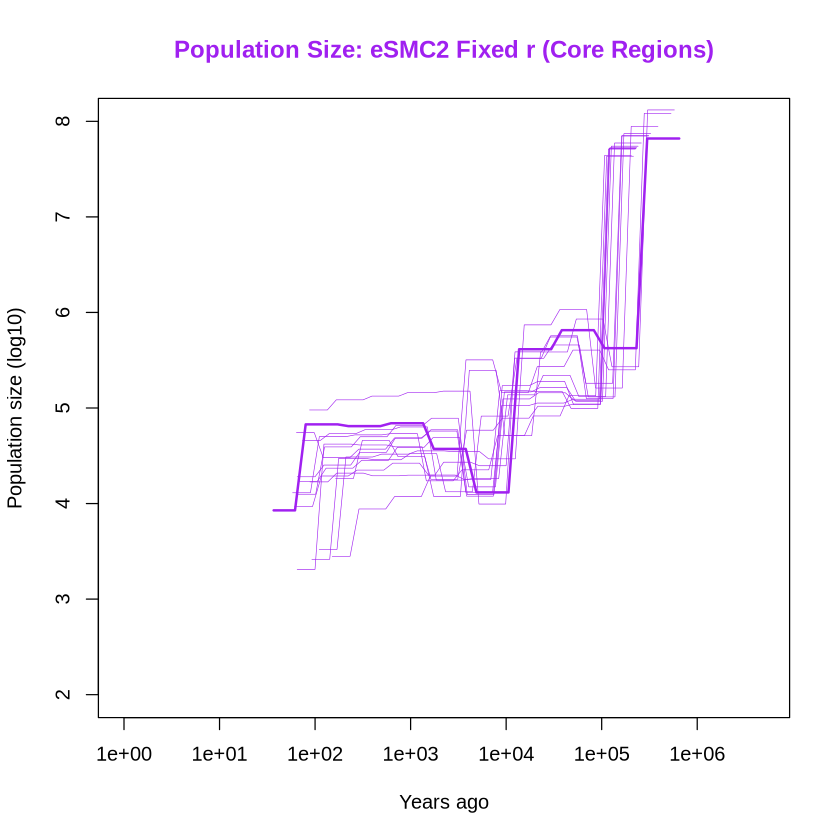

In [12]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.164      # Generation time

par(bg = "white")  # Applies white background to all plots

# Function to set up the plotting area
setup_plot <- function(title, color) {
  plot(c(1000, 5 * 10^7), 
       c(1, 1), 
       log = "x", 
       ylim = c(2, 8), 
       xlim = c(1, 5 * 10^6), 
       type = "n", 
       xlab = "Years ago", 
       ylab = "Population size (log10)", 
       main = title, 
       col.main = color)
}

# Plot for eSMC2 Free r Full Chromosomes
setup_plot("Population Size: eSMC2 Free r (Full Chromosomes)", "darkgreen")
for (chr in names(plot_data_list_newhetfile_esmc2_free_r)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}

# Plot for eSMC2 Free r Core Regions
setup_plot("Population Size: eSMC2 Free r (Core Regions)", "darkorange")
for (chr in names(plot_data_list_newhetfile_esmc2_regions)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "darkorange", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_esmc2_regions[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkorange", lwd = 2)
}

# Plot for eSMC2 Fixed r Core Regions
setup_plot("Population Size: eSMC2 Fixed r (Core Regions)", "purple")
for (chr in names(plot_data_list_newhetfile_esmc2_regions_fixed_r)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "purple", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "purple", lwd = 2)
}

In [27]:
mu <- 2.0625e-8 # Default mutation rate
gen <- 0.5  # Generation time
png("upperlower_ncv.png", width = 1700, height = 1800, res = 300)  # Higher resolution

par(bg = "white")  # Applies white background to all plots

# Set up plot area with logarithmic x-axis
plot(c(1000, 5 * 10^7), 
     c(1, 1), 
     log = "x", 
     ylim = c(-1, 9), 
     xlim = c(1, 5 * 10^6), 
     type = "n", 
     xlab = "Years ago", 
     ylab = "Population size (log10)", 
     main = paste("Population Size, NCV Subpopulation", 
             "(Full Chromosome vs Subset regions)", sep = "\n"))

# Plot "All Chromosome" lines in bold
# eSMC2 Free_r "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2, lty=4)
}

# eSMC2 Fixed_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "purple", lwd = 2, lty=4)
}

# eSMC2 Free_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkorange", lwd = 2, lty=4)
}

# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.16    # Generation time

# Loop through each chromosome to plot lighter lines for individual chromosomes
for (chr in names(plot_data_list_newhetfile_esmc2_free_r)) {

  # Skip "allchr" as it will be plotted separately
  if (chr != "allchr") {
    # eSMC2 Free_r plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)  # Fixed mu for Free_r
      lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkgreen", lwd = 0.25, lty = 1)  # Green for Free_r, lower limit
    }
    
    # eSMC2 Free_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_regions[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$mu / mu)  # Fixed mu for Regions
      lines(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkorange", lwd = 0.25, lty = 1)  # Orange for Free_r Regions, lower limit
    }
    
    # eSMC2 Fixed_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$mu / mu)  # Fixed mu for Fixed_r
      lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "purple", lwd = 0.25, lty = 1)  # Purple for Fixed_r Regions, lower limit
    }
  }
}

# Plot "All Chromosome" lines in bold
# eSMC2 Free_r "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2, lty = 1)
}

# eSMC2 Fixed_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "purple", lwd = 2, lty = 1)
}

# eSMC2 Free_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkorange", lwd = 2, lty = 1)
}

# Add a legend for the main lines
types <- c("lower limit", "upper limit")
legend("bottomleft", 
       legend = c(
         paste("eSMC2 Free r Full Chromosomes - ","\n" ,types,"\n"),
         paste("eSMC2 Free r Core Regions - ", "\n",types,"\n"),
         paste("eSMC2 Fixed r Core Regions - ","\n" ,types,"\n")
       ),
       col = c("darkgreen", "darkorange", "purple"), 
       cex=0.7,
       lty = c(1, 2), 
       lwd = 2, ncol = 2)

dev.off()

pdf 
  2

In [17]:
mu <- 2.0625e-8 # Default mutation rate
gen <- 0.5 

Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
x<-plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen
y<-log10(Ne_t * Ne)

# Subset data for x between 1000 and 10000
subset_data <- data.frame(x = x[x >= 1000 & x <= 100000], y = y[x >= 1000 & x <= 100000])

# Find the index of the minimum y-value in the subset
min_y_index <- which.min(subset_data$y)

# Get the corresponding x value for the minimum y
min_x_value <- subset_data$x[min_y_index]

# Print the result
print(min_x_value)

[1] 2873.201


In [18]:
subset_data

x,y
<dbl>,<dbl>
1026.904,4.254951
1328.125,4.254951
1717.702,4.224617
2221.554,4.224617
2873.201,3.298180
3715.995,3.298180
4806.004,4.673650
6215.745,4.673650
8039.004,4.654013


In [19]:

# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.16    #
Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
x<-plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen
y<-log10(Ne_t * Ne)

# Subset data for x between 1000 and 10000
subset_data <- data.frame(x = x[x >= 1000 & x <= 100000], y = y[x >= 1000 & x <= 100000])

# Find the index of the minimum y-value in the subset
min_y_index <- which.min(subset_data$y)

# Get the corresponding x value for the minimum y
min_x_value <- subset_data$x[min_y_index]

# Print the result
print(min_x_value)


[1] 4690.941


In [20]:
subset_data

x,y
<dbl>,<dbl>
1002.318,4.849689
1296.327,4.849689
1676.578,4.962695
2168.367,4.962695
2804.412,4.932361
3627.028,4.932361
4690.941,4.005924
6066.930,4.005924
7846.537,5.381394


In [17]:
# Initialize vectors for rho, mu, rho/mu, chromosomes, and categories
rho_values <- c()
mu_values <- c()
rho_mu_ratios <- c()
chromosomes <- c()
category_labels <- c()

# Function to process data from a given list and category
process_data <- function(data_list, category_label) {
    for (chr in as.numeric(names(data_list))) {
        chr_data <- data_list[[chr]][[1]]
        
        if (!is.null(chr_data$rho) && !is.null(chr_data$mu)) {
            rho_values <<- c(rho_values, mean(chr_data$rho))
            mu_values <<- c(mu_values, chr_data$mu)
            rho_mu_ratios <<- c(rho_mu_ratios, mean(chr_data$rho) / chr_data$mu)
            chromosomes <<- c(chromosomes, chr)
            category_labels <<- c(category_labels, as.character(category_label))
        }
    }
}

process_data(plot_data_list_newhetfile_esmc2_regions, "Free r Core Regions")
process_data(plot_data_list_newhetfile_esmc2_regions_fixed_r, "Fixed r Core Regions")
rho_values


Warning message in process_data(plot_data_list_newhetfile_esmc2_regions, "Free r Core Regions"):
“NAs introduced by coercion”
Warning message in process_data(plot_data_list_newhetfile_esmc2_regions_fixed_r, :
“NAs introduced by coercion”


[1] 0.010376855 0.011019351 0.006971490 0.027801288 0.013268126 0.004626523
 [7] 0.008979205 0.016573203 0.009174169 0.005146441 0.007739283 0.027934632
[13] 0.008678624 0.015314556 0.082445900 0.050473578 0.040301372 0.089416387
[19] 0.037312002 0.035421040 0.060187751 0.048215294 0.034792990 0.047710940
[25] 0.035990052 0.031719265 0.035446586 0.033349466

In [18]:

# Function to process data from a given list and category
process_data <- function(data_list, category_label) {
    for (chr in names(data_list)) {
        chr_data <- data_list[[chr]]
        
        if (!is.null(chr_data$rho) && !is.null(chr_data$mu)) {
            rho_values <<- c(rho_values, mean(chr_data$rho))
            mu_values <<- c(mu_values, chr_data$mu)
            rho_mu_ratios <<- c(rho_mu_ratios, mean(chr_data$rho) / chr_data$mu)
            chromosomes <<- c(chromosomes, chr)
            category_labels <<- c(category_labels, as.character(category_label))
        }
    }
}

# Process data for all categories

process_data(plot_data_list_newhetfile_esmc2_free_r, "Free r Full Chromosome")
process_data(plot_data_list_newhetfile_esmc2, "Fixed r Full Chromosome")

length(rho_values)
length(category_labels)

[1] 58

[1] 58

In [19]:

# Create a data frame for plotting
boxplot_data <- data.frame(
    chromosomes= chromosomes,
    Rho = rho_values,
    Mu = mu_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Category = factor(category_labels, levels = c("Free r Core Regions", "Free r Full Chromosome", "Fixed r Core Regions", "Fixed r Full Chromosome")) # Ensure correct category order
)
boxplot_data

chromosomes,Rho,Mu,Rho_Mu_Ratio,Category
<chr>,<dbl>,<dbl>,<dbl>,<fct>
1,0.010376855,0.0004836112,21.457018,Free r Core Regions
2,0.011019351,0.0003026125,36.414063,Free r Core Regions
3,0.006971490,0.0002391816,29.147273,Free r Core Regions
4,0.027801288,0.0005207335,53.388708,Free r Core Regions
5,0.013268126,0.0002228938,59.526675,Free r Core Regions
6,0.004626523,0.0002088736,22.149865,Free r Core Regions
7,0.008979205,0.0003559289,25.227526,Free r Core Regions
8,0.016573203,0.0002860642,57.935251,Free r Core Regions
9,0.009174169,0.0002085323,43.993995,Free r Core Regions


Warning message:
“Removed 29 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 29 rows containing non-finite outside the scale range
(`stat_summary()`).”


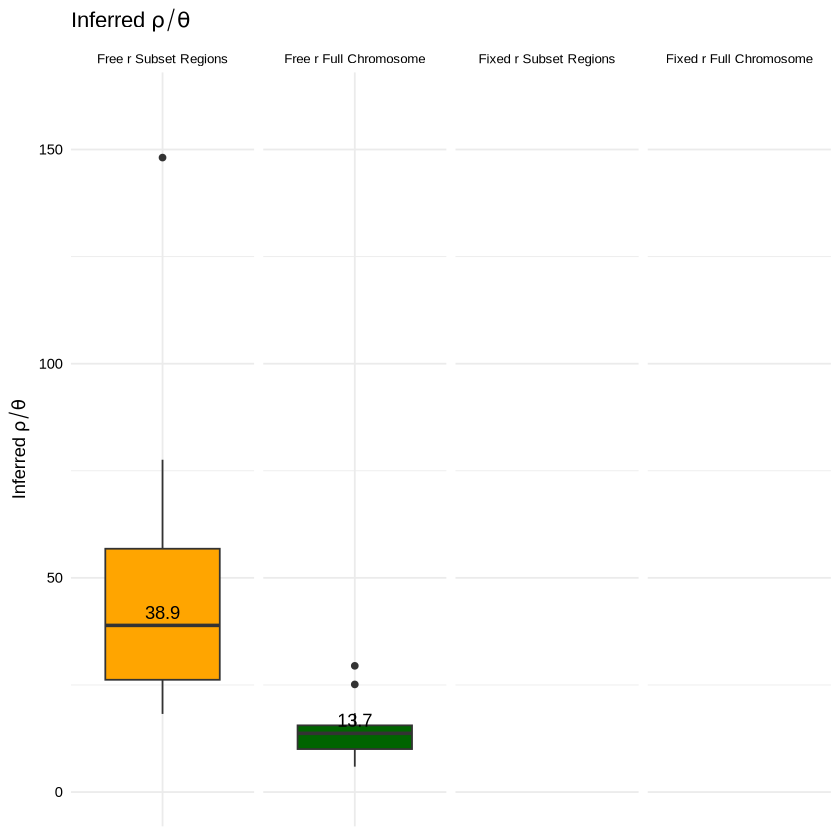

In [28]:
# Boxplot for Rho/Mu with median labels
plot_rho_mu <- ggplot(boxplot_data, aes(x = Category, y = Rho_Mu_Ratio, fill = Category)) +
    geom_boxplot() +
    labs(
        title = expression("Inferred " * rho / theta),  # Title with inferred rho/mu
        y = expression("Inferred " * rho / theta)      # Y-axis label with inferred rho/mu
    ) +
    scale_fill_manual(
        values = c("orange", "darkgreen", "purple", "lightcoral"),
        name = "Category"
    ) +
    theme_minimal() +

    facet_wrap(~Category, scales = "free_x", ncol = 4) +  # Separate plots by Category
    stat_summary(
        fun = median, 
        geom = "text", 
        aes(label = round(..y.., 1)),                  # Round median to 1 decimal place
        position = position_dodge(width = 0.75), 
        vjust = -0.5,                                 # Adjust position of text
        color = "black"                               # Set text color
    ) +
   ylim(0,160)+
    theme(
        axis.text.x = element_blank(),               # Remove x-axis tick labels
        axis.title.x = element_blank(),              # Remove x-axis label
        axis.text = element_text(color = "black"),   # Black tick labels
        axis.title = element_text(color = "black"),  # Black axis labels
        plot.title = element_text(color = "black"),  # Black plot title
        strip.text = element_text(size = 8, color = "black"),  # Category labels font size and color
        legend.position = "none"                     # Remove legend
    )

# Display the plot
plot_rho_mu


In [21]:
# Load ggplot2 package
library(ggplot2)

# Initialize empty vectors to store rho, mu, and rho/mu values for both Free_r Regions and Free_r Full
rho_values <- c()
mu_values <- c()
rho_mu_ratios <- c()
chromosomes <- c()  # To store valid chromosome names
category_labels <- c()  # To store categories (Free_r Regions vs. Free_r Full)

# Loop through each chromosome in the data list
for (chr in c(as.numeric(names(plot_data_list_newhetfile_esmc2_regions)[-15], as.character("allchr")))) {
    chr_data <- plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]  # Access the first (and only) element in the list for the chromosome
    
    # Ensure the data is not NULL and contains valid rho, mu, and rho/mu values
    if (!is.null(chr_data$rho) && !is.null(chr_data$mu)) {
        # Append data to the vectors
        rho_values <- c(rho_values, chr_data$rho)
        mu_values <- c(mu_values, chr_data$mu)
        rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
        chromosomes <- c(chromosomes, chr)  # Add chromosome name to list
    }
}
category_labels <- c(category_labels, rep("Free_r Regions", 14))  # Label as Free_r Regions
# Loop through each chromosome in the `Free_r Full` data
for (chr in c(names(plot_data_list_newhetfile_esmc2_free_r))) {
    chr_data <- plot_data_list_newhetfile_esmc2_free_r[[chr]]  # Access the data for the chromosome
    
    # Ensure the data is not NULL and contains valid rho, mu, and rho/mu values
    if (!is.null(chr_data$rho) && !is.null(chr_data$mu)) {
        # Append data to the vectors
        rho_values <- c(rho_values, chr_data$rho[1])
        mu_values <- c(mu_values, chr_data$mu)
        rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho[1] / chr_data$mu)
        chromosomes <- c(chromosomes, chr)  # Add chromosome name
    }
}
category_labels <- c(category_labels, rep("Free_r Full", 13))  # Label as Free_r Full

# Create a data frame for plotting
boxplot_data <- data.frame(
    Rho = rho_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Mu = mu_values,
    Category = category_labels
)
boxplot_data


ERROR: Error in data.frame(Rho = rho_values, Rho_Mu_Ratio = rho_mu_ratios, Mu = mu_values, : arguments imply differing number of rows: 29, 27


In [40]:

# Boxplot for Rho
plot_rho <- ggplot(boxplot_data, aes(x = Category, y = Rho, fill = Category)) +
    geom_boxplot() +
    labs(title = expression(rho), y = expression(rho)) +
    scale_fill_manual(values = c("lightblue", "lightgreen"), name = "Category") + # Shared legend
    theme_minimal() +
    theme(
        axis.text.x = element_blank(),               # Remove x-axis tick labels
        axis.title.x = element_blank(),              # Remove x-axis label
        axis.text = element_text(color = "black"),   # Black tick labels
        axis.title = element_text(color = "black"),  # Black axis labels
        plot.title = element_text(color = "black")   # Black plot title
    )

# Boxplot for Mu
plot_mu <- ggplot(boxplot_data, aes(x = Category, y = Mu, fill = Category)) +
    geom_boxplot() +
    labs(title = expression(mu), y = expression(mu)) +
    scale_fill_manual(values = c("lightblue", "lightgreen"), name = "Category") + # Shared legend
    theme_minimal() +
    theme(
        axis.text.x = element_blank(),               # Remove x-axis tick labels
        axis.title.x = element_blank(),              # Remove x-axis label
        axis.text = element_text(color = "black"),   # Black tick labels
        axis.title = element_text(color = "black"),  # Black axis labels
        plot.title = element_text(color = "black")   # Black plot title
    )

# Boxplot for Rho/Mu
plot_rho_mu <- ggplot(boxplot_data, aes(x = Category, y = Rho_Mu_Ratio, fill = Category)) +
    geom_boxplot() +
    labs(title = expression(rho / mu), y = expression(rho / mu)) +
    scale_fill_manual(values = c("lightblue", "lightgreen"), name = "Category") + # Shared legend
    theme_minimal() +
    theme(
        axis.text.x = element_blank(),               # Remove x-axis tick labels
        axis.title.x = element_blank(),              # Remove x-axis label
        axis.text = element_text(color = "black"),   # Black tick labels
        axis.title = element_text(color = "black"),  # Black axis labels
        plot.title = element_text(color = "black")   # Black plot title
    )

# Combine the plots with one shared legend at the bottom
combined_plot <- (plot_rho + plot_mu + plot_rho_mu) +
    plot_layout(guides = "collect") &                 # Combine legends
    theme(legend.position = "bottom")                 # Place legend at the bottom

# Add a header using plot_annotation()
combined_plot <- combined_plot +
    plot_annotation(
        title = "Comparison of Rho, Mu, and Rho/Mu Across Categories",
        theme = theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5, color = "black") # Centered and bold title
        )
    )

# Display the combined plot
print(combined_plot)


ERROR: [1m[33mError[39m in `palette()`:[22m
[1m[22m[33m![39m Insufficient values in manual scale. 4 needed but only 2 provided.


In [22]:
# Initialize vectors for rho, mu, rho/mu, chromosomes, and categories
rho_values <- c()
mu_values <- c()
rho_mu_ratios <- c()
chromosomes <- c()
category_labels <- c()

# Function to process data from a given list and category
process_data <- function(data_list, category_label) {
    for (chr in as.numeric(names(data_list))) {
        chr_data <- data_list[[chr]][[1]]
        
        if (!is.null(chr_data$rho) && !is.null(chr_data$mu)) {
            rho_values <<- c(rho_values, chr_data$rho[1])
            mu_values <<- c(mu_values, chr_data$mu)
            rho_mu_ratios <<- c(rho_mu_ratios, chr_data$rho[1] / chr_data$mu)
            chromosomes <<- c(chromosomes, chr)
            category_labels <<- c(category_labels, as.character(category_label))
        }
    }
}

process_data(plot_data_list_newhetfile_esmc2_regions, "Free r Subset Regions")
process_data(plot_data_list_newhetfile_esmc2_regions_fixed_r, "Fixed r Subset Regions")



rho_mu_ratios

Warning message in process_data(plot_data_list_newhetfile_esmc2_regions, "Free r Subset Regions"):
“NAs introduced by coercion”
Warning message in process_data(plot_data_list_newhetfile_esmc2_regions_fixed_r, :
“NAs introduced by coercion”


[1]  21.45702  36.41406  29.14727  53.38871  59.52667  22.14987  25.22753
 [8]  57.93525  43.99400  18.23265  36.29882 148.11316  41.39060  77.57208
[15] 168.08631 168.08631 168.08631 168.08631 168.08631 168.08631 168.08631
[22] 168.08631 168.08631 168.08631 168.08631 168.08631 168.08631 168.08631

In [23]:
# Function to process data from a given list and category
process_data <- function(data_list, category_label) {
    for (chr in names(data_list)) {
        chr_data <- data_list[[chr]]
        
        if (!is.null(chr_data$rho) && !is.null(chr_data$mu)) {
            rho_values <<- c(rho_values, chr_data$rho[1])
            mu_values <<- c(mu_values, chr_data$mu)
            rho_mu_ratios <<- c(rho_mu_ratios, chr_data$rho[1] / chr_data$mu)
            chromosomes <<- c(chromosomes, chr)
            category_labels <<- c(category_labels, as.character(category_label))
        }
    }
}

# Process data for all categories

process_data(plot_data_list_newhetfile_esmc2_free_r, "Free r Full Chromosome")
process_data(plot_data_list_newhetfile_esmc2, "Fixed r Full Chromosome")

# Create a data frame for plotting
boxplot_data <- data.frame(
    Rho = rho_values,
    Mu = mu_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Category = factor(category_labels, levels = c("Free r Subset Regions", "Free r Full Chromosome", "Fixed r Subset Regions", "Fixed r Full Chromosome")) # Ensure correct category order
) # Ensure correct category orde
boxplot_data

Rho,Mu,Rho_Mu_Ratio,Category
<dbl>,<dbl>,<dbl>,<fct>
0.010376855,0.0004836112,21.457018,Free r Subset Regions
0.011019351,0.0003026125,36.414063,Free r Subset Regions
0.006971490,0.0002391816,29.147273,Free r Subset Regions
0.027801288,0.0005207335,53.388708,Free r Subset Regions
0.013268126,0.0002228938,59.526675,Free r Subset Regions
0.004626523,0.0002088736,22.149865,Free r Subset Regions
0.008979205,0.0003559289,25.227526,Free r Subset Regions
0.016573203,0.0002860642,57.935251,Free r Subset Regions
0.009174169,0.0002085323,43.993995,Free r Subset Regions


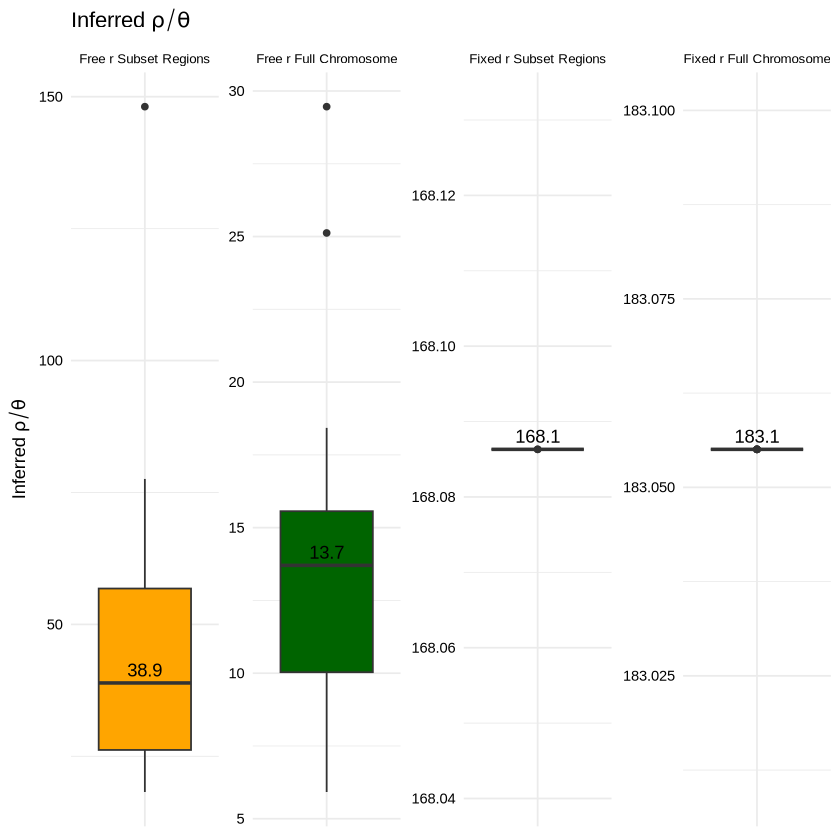

In [24]:
# Boxplot for Rho
plot_rho <- ggplot(boxplot_data, aes(x = Category, y = Rho, fill = Category)) +
    geom_boxplot() +
    labs(
        title = expression("Inferred " * rho),        # Title with inferred rho
        y = expression("Inferred " * rho)            # Y-axis label with inferred rho
    ) +
    scale_fill_manual(
        values = c("lightblue", "lightgreen", "lightcoral", "lightgoldenrod"),
        name = "Category"
    ) +
    theme_minimal() +
    theme(
        axis.text.x = element_blank(),               # Remove x-axis tick labels
        axis.title.x = element_blank(),              # Remove x-axis label
        axis.text = element_text(color = "black"),   # Black tick labels
        axis.title = element_text(color = "black"),  # Black axis labels
        plot.title = element_text(color = "black")   # Black plot title
    )

# Boxplot for Mu
plot_mu <- ggplot(boxplot_data, aes(x = Category, y = Mu, fill = Category)) +
    geom_boxplot() +
    labs(
        title = expression("Inferred " * mu),        # Title with inferred mu
        y = expression("Inferred " * mu)            # Y-axis label with inferred mu
    ) +
    scale_fill_manual(
        values = c("lightblue", "lightgreen", "lightcoral", "lightgoldenrod"),
        name = "Category"
    ) +
    theme_minimal() +
    theme(
        axis.text.x = element_blank(),               # Remove x-axis tick labels
        axis.title.x = element_blank(),              # Remove x-axis label
        axis.text = element_text(color = "black"),   # Black tick labels
        axis.title = element_text(color = "black"),  # Black axis labels
        plot.title = element_text(color = "black")   # Black plot title
    )

# Boxplot for Rho/Mu with median labels
plot_rho_mu <- ggplot(boxplot_data, aes(x = Category, y = Rho_Mu_Ratio, fill = Category)) +
    geom_boxplot() +
    labs(
        title = expression("Inferred " * rho / theta),  # Title with inferred rho/mu
        y = expression("Inferred " * rho / theta)      # Y-axis label with inferred rho/mu
    ) +
    scale_fill_manual(
        values = c("orange", "darkgreen", "purple", "lightcoral"),
        name = "Category"
    ) +
    theme_minimal() +

    facet_wrap(~Category, scales = "free", ncol = 4) +  # Separate plots by Category
    stat_summary(
        fun = median, 
        geom = "text", 
        aes(label = round(..y.., 1)),                  # Round median to 1 decimal place
        position = position_dodge(width = 0.75), 
        vjust = -0.5,                                 # Adjust position of text
        color = "black"                               # Set text color
    ) +
    theme(
        axis.text.x = element_blank(),               # Remove x-axis tick labels
        axis.title.x = element_blank(),              # Remove x-axis label
        axis.text = element_text(color = "black"),   # Black tick labels
        axis.title = element_text(color = "black"),  # Black axis labels
        plot.title = element_text(color = "black"),  # Black plot title
        strip.text = element_text(size = 8, color = "black"),  # Category labels font size and color
        legend.position = "none"                     # Remove legend
    )

# Display the plot
plot_rho_mu

